In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths
strain_seq_path = "metadata/wt_strain_seqs.csv"

# Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import metapredict
import ast
from Bio.Seq import Seq

## TF Sequences

In [4]:
seq_metadata = pd.read_csv(strain_seq_path)
seq_metadata.rename(columns={'TF Name': 'Name'}, inplace=True)
seq_metadata.rename(columns={'DNA_seq': 'Strain seq'}, inplace=True)

In [5]:
seq_metadata['AA_seq'] = seq_metadata['Strain seq'].apply(lambda nt: str(Seq(nt).translate()))
seq_metadata['AA_seq'] = seq_metadata['AA_seq'].fillna('').astype(str).str.rstrip(' *')
seq_metadata['AA_seq'] = seq_metadata['AA_seq'].fillna('').astype(str).str.rstrip('*')

## Disorder prediction data

In [6]:
# Function to run predict_disorder with progress logging
def predict_disorder(sequence, index):
    try:
        if pd.notna(sequence):
            return metapredict.predict_disorder(sequence)
        else:
            return None  # Handle missing sequence
    except Exception as e:
        return str(e)  # Return the error message if an exception occurs

In [7]:
seq_metadata['metapredict'] = ''
seq_metadata['metapredict'] = [predict_disorder(seq, idx) for idx, seq in enumerate(seq_metadata['AA_seq'])]
seq_metadata['metapredict'] = seq_metadata['metapredict'].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x)

## Domains within TFs

In [8]:
interpro_data = pd.read_csv("metadata/interpro_results.csv", index_col=0)
interpro = interpro_data[interpro_data["3"]=="Pfam"]

In [9]:
dna_binding_domains = [
    'ARID/BRIGHT DNA binding domain',
    'RFX DNA-binding domain',
    'AT hook motif',
    'Transcription factor AP-2',
    'SNF2-related domain',
    'AT-hook-containing transcription factor',
    'Helix-loop-helix DNA-binding domain',
    'PHD finger protein 20, AT-hook',
    'BED zinc finger',
    'Hypoxia-inducible factor 1-alpha bHLH domain',
    'Myogenic Basic domain',
    'Nuclear receptor coactivators bHLH domain',
    'NPAS4 bHLH domain',
    'Neuronal helix-loop-helix transcription factor',
    'Tc5 transposase DNA-binding domain',
    'Brinker DNA-binding domain',
    'bZIP transcription factor',
    'Basic region leucine zipper',
    'bZIP Maf transcription factor',
    'C2H2-type zinc finger',
    'Zinc finger, C2H2 type',
    'ASCIZ forth C2H2 zinc finger domain',
    'ASCIZ fist and second C2H2 zinc finger domains',
    'ASCIZ third C2HC zinc finger domain',
    'Zinc-finger double domain',
    'C2H2 zinc finger',
    'Zinc-finger of C2H2 type',
    'TFIIIA, beta-beta-alpha zinc finger',
    'MYST family zinc finger domain',
    'Zinc finger, C2HC type',
    'Domain of Kin17 curved DNA-binding protein',
    'Myelin transcription factor 1',
    'PRDM15 C2H2 zinc finger domain',
    'REST-like, C2H2-type zinc finger',
    'Protein arginine N-methyltransferase 3, C2H2 zinc finger domain',
    'Protein arginine N-methyltransferase 3, C2H2 zinc finger',
    'PR zinc knuckle motif',
    'TRAFD1/XAF1, zinc finger',
    'Zinc Finger domain',
    'Zinc finger found in WIZ protein',
    'C2H2-type zinc-finger domain',
    'Zic proteins zinc finger domain',
    'Zfx / Zfy transcription activation region',
    'Zinc finger protein ZFPM1-like, PR domain',
    'Myb/SANT-like DNA-binding domain',
    'Zinc finger protein 142 C2H2 domain',
    'ZN142 C2H2 zinc finger',
    'C2H2-type zinc ribbon',
    'zinc-finger of a C2HC-type',
    'F-box only protein 41 C2H2 zinc finger',
    'Sixth Zinc fingers C2H2 type, ZNF451',
    'Two consecutive Zinc fingers C2H2 type, ZNF451',
    'First Zinc fingers C2H2 type, ZNF451',
    'Second Zinc fingers C2H2 type, ZNF451',
    'Fifth Zinc fingers C2H2 type, ZNF451',
    'NocA-like zinc-finger protein 1',
    'Zinc finger protein 462, first C2H2 zinc finger',
    'Zinc finger protein 462, C2H2 zinc finger',
    'Zinc finger protein 462, seventh C2H2 zinc finger',
    'Zinc finger protein 462, second C2H2 zinc finger',
    'Zinc finger protein 512, C2HC zinc finger',
    'Unstructured conserved, between two C2H2-type zinc-fingers',
    'zinc-finger C2H2-type',
    'ZNF598 C2H2 zinc finger domain',
    'C2H2 Hakai zinc finger domain',
    'Zinc finger homeobox protein 3-like, C2H2 type zinc-finger',
    'Homeodomain',
    'CENP-B N-terminal DNA-binding domain',
    'LAG1, DNA binding',
    'Beta-trefoil DNA-binding domain',
    "'Cold-shock' DNA-binding domain",
    'CUT domain',
    'CUT1-like DNA-binding domain of SATB',
    'DM DNA binding domain',
    'E2F/DP family winged-helix DNA-binding domain',
    'CXXC zinc finger domain',
    'CpG binding protein C-terminal domain',
    'C-5 cytosine-specific DNA methylase',
    'Cytosine specific DNA methyltransferase replication foci domain',
    'Transcription factor COE1 DNA-binding domain',
    'Ets-domain',
    'Forkhead domain',
    'GATA zinc finger',
    'HMG (high mobility group) box',
    'GCM motif protein',
    'CP2 transcription factor',
    'Homeobox KN domain',
    'PBC domain',
    "'Paired box' domain",
    'Homeodomain leucine-zipper encoding, Homez',
    'Zinc-fingers and homeoboxes C2H2 finger domain',
    'Interferon regulatory factor transcription factor',
    'HSF-type DNA-binding',
    'Pou domain - N-terminal to homeobox domain',
    'Myb-like DNA-binding domain',
    'SRF-type transcription factor (DNA-binding and dimerisation domain)',
    'Telomere repeat binding factor (TRF)',
    'NF-X1 type zinc finger',
    'NDT80 / PhoG like DNA-binding family',
    'Histone-like transcription factor (CBF/NF-Y) and archaeal histone',
    'Transcription factor TFIIB repeat',
    'BEN domain',
    'SAP domain',
    'NLS-binding and DNA-binding and dimerisation domains of Nrf1',
    'Rel homology DNA-binding domain',
    'TATA element modulatory factor 1 DNA binding',
    'P53 DNA-binding domain',
    'Small nuclear RNA activating complex (SNAPc), subunit 2',
    'helix-turn-helix, Psq domain',
    'XPA protein C-terminus',
    'RFX5 DNA-binding domain',
    'STAT protein, DNA binding domain',
    'Transcription factor TFIID (or TATA-binding protein, TBP)',
    'TEA/ATTS domain',
    'THAP domain',
    'T-box'
]

In [10]:
# Initialize new columns in metadata3 to hold domain location data
seq_metadata['DBD_locations'] = [[] for _ in range(len(seq_metadata))]
seq_metadata['other_domain_locations'] = [[] for _ in range(len(seq_metadata))]

In [11]:
# Iterate through metadata3 rows
for index, row in seq_metadata.iterrows():
    TF_name = row['Name']

    # Filter rows in interpro that match the transcript_id
    matching_rows = interpro[interpro["0"] == TF_name]

    for _, match in matching_rows.iterrows():
        domain_tuple = (match["6"], match["7"])  # Start and end locations of domain
        
        if match["5"] in dna_binding_domains:  # Column "5" contains the domain type
            seq_metadata.at[index, 'DBD_locations'].append(domain_tuple)
        else:
            seq_metadata.at[index, 'other_domain_locations'].append(domain_tuple)

## Process IDR and DBD sequences

In [12]:
# Calculate the total length of DNA-binding domains from a list of (start, end) tuples.
def calculate_domain_length(dbd_locations):
    if isinstance(dbd_locations, str):
        dbd_locations = ast.literal_eval(dbd_locations)   
    # Sum the domain lengths
    return sum([end - start + 1 for start, end in dbd_locations])

In [13]:
seq_metadata['domain_length'] = seq_metadata['DBD_locations'].apply(calculate_domain_length)

### IDR and non-IDR positions, lengths, and sequences

In [14]:
# Parse the metapredict column and return a list of disorder scores
def process_metapredict(metapredict):
    if isinstance(metapredict, str) and metapredict:
        try:
            return list(map(float, metapredict.split(', ')))
        except ValueError:
            print("Warning: metapredict parsing error.")
            return []
    elif isinstance(metapredict, (list, tuple)):
        return list(map(float, metapredict))
    return []

In [15]:
# Identify positions outside DBD regions.
def process_non_dbd_positions(aa_seq, dbd_locations):
    if not isinstance(aa_seq, str) or len(aa_seq) == 0:
        return []
    if isinstance(dbd_locations, str) and dbd_locations:
        try:
            dbd_locations = ast.literal_eval(dbd_locations)
        except Exception as e:
            print(f"Warning: Error parsing DBD locations: {e}")
            dbd_locations = []
    elif isinstance(dbd_locations, (list, tuple)):
        dbd_locations = list(dbd_locations)
    else:
        dbd_locations = []

    non_dbd_positions = set(range(len(aa_seq)))
    for start, end in dbd_locations:
        try:
            s, e = int(start), int(end)
        except Exception:
            continue
        non_dbd_positions -= set(range(s, e + 1))
    
    return sorted(non_dbd_positions)

In [16]:
# Extract IDR sequences based on disorder scores and non-DBD positions.
def extract_idr_from_positions(aa_seq, disorder_scores, non_dbd_positions, disorder_cutoff=0.5):
    idr_sequences = []
    current_idr_seq = []
    for pos in non_dbd_positions:
        if pos < len(disorder_scores) and disorder_scores[pos] >= disorder_cutoff:
            current_idr_seq.append(aa_seq[pos])
        else:
            if current_idr_seq:
                idr_sequences.append(''.join(current_idr_seq))
                current_idr_seq = []
    if current_idr_seq:
        idr_sequences.append(''.join(current_idr_seq))
    return idr_sequences

In [17]:
# Main function to extract IDR sequences for a single transcription factor row.
def extract_idr_sequences(tf_row, disorder_cutoff=0.5):
    aa_seq = tf_row['AA_seq']
    disorder_scores = process_metapredict(tf_row['metapredict'])
    if not disorder_scores:
        return []
    non_dbd_positions = process_non_dbd_positions(aa_seq, tf_row['DBD_locations'])
    return extract_idr_from_positions(aa_seq, disorder_scores, non_dbd_positions, disorder_cutoff)

In [18]:
def extract_dbd_sequences(tf_row):
    aa_seq = tf_row.get('AA_seq', '')
    dbd_locs = tf_row.get('DBD_locations', [])
    # Parse if string
    if isinstance(dbd_locs, str):
        try:
            dbd_locs = ast.literal_eval(dbd_locs)
        except Exception:
            return []
    if not isinstance(dbd_locs, (list, tuple)) or not dbd_locs:
        return []
    seq_len = len(aa_seq)
    dbd_seqs = []
    for start, end in dbd_locs:
        try:
            s = max(int(start), 0)
            e = min(int(end), seq_len - 1)
        except Exception:
            continue
        if s <= e:
            dbd_seqs.append(aa_seq[s:e+1])
    return dbd_seqs

In [19]:
def extract_non_dbd_sequences(tf_row):
    aa_seq = tf_row.get('AA_seq', '')
    if not isinstance(aa_seq, str) or len(aa_seq) == 0:
        return []
    non_dbd_positions = process_non_dbd_positions(aa_seq, tf_row.get('DBD_locations', []))
    if not non_dbd_positions:
        return []
    segments = []
    current = []
    for pos in non_dbd_positions:
        if not current or pos == current[-1] + 1:
            current.append(pos)
        else:
            segments.append(''.join(aa_seq[i] for i in current))
            current = [pos]
    if current:
        segments.append(''.join(aa_seq[i] for i in current))
    return segments

In [20]:
seq_metadata['IDR_sequences'] = seq_metadata.apply(lambda row: extract_idr_sequences(row, disorder_cutoff=0.5), axis=1)
seq_metadata['DBD_sequences'] = seq_metadata.apply(extract_dbd_sequences, axis=1)
seq_metadata['non_DBD_sequences'] = seq_metadata.apply(extract_non_dbd_sequences, axis=1)

In [21]:
# Calculate the total number of IDR, non-IDR, and non-DBD residues based on disorder scores and non-DBD positions
def count_idr_non_idr_residues(disorder_scores, non_dbd_positions, disorder_cutoff=0.5):
    idr_count = 0
    non_idr_count = 0

    for pos in non_dbd_positions:
        if pos < len(disorder_scores):
            if disorder_scores[pos] >= disorder_cutoff:
                idr_count += 1
            else:
                non_idr_count += 1
    non_dbd_count = len(non_dbd_positions)
    return idr_count, non_idr_count, non_dbd_count

In [22]:
seq_metadata[['IDR_count', 'Non_IDR_count', 'Non_DBD_count']] = seq_metadata.apply(
    lambda row: pd.Series(count_idr_non_idr_residues(
        process_metapredict(row['metapredict']),
        process_non_dbd_positions(row['AA_seq'], row['DBD_locations']),
        disorder_cutoff=0.5
    )),
    axis=1
)

### IDR hydrophobic residue metrics

In [23]:
# Calculate the mean distance, standard deviation between hydrophobic residues, and the total count of hydrophobic residues in a list of IDR sequences
def calculate_hydrophobic_metrics(idr_sequences, hydrophobic_AAs):
    all_distances = []
    total_hydrophobic_count = 0
    
    for seq in idr_sequences:
        # Collect positions of hydrophobic residues in the current IDR sequence
        positions = [i for i, res in enumerate(seq) if res in hydrophobic_AAs]
        
        # Update total count
        total_hydrophobic_count += len(positions)
        
        # Calculate distances between consecutive hydrophobic residues
        distances = [positions[i+1] - positions[i] for i in range(len(positions) - 1)]
        all_distances.extend(distances)
    
    # Calculate mean and standard deviation for all distances across IDR sequences
    if all_distances:
        mean_distance = np.mean(all_distances)
        # Avoid computing std if there are fewer than 2 distances
        std_distance = np.std(all_distances) if len(all_distances) > 1 else 0
    else:
        mean_distance = 0
        std_distance = 0

    return mean_distance, std_distance, total_hydrophobic_count

In [24]:
hydrophobic_AAs = ["G", "A", "V", "P", "L", "I", "M", "W", "F"]  # Expanded defintion of hydrophobic amino acids
seq_metadata[['mean_hydrphb_dist', 'stdv_hydrophb_dist', 'hydrophb_count']] = seq_metadata['IDR_sequences'].apply(lambda x: pd.Series(calculate_hydrophobic_metrics(x, hydrophobic_AAs)))

### Propensity to form alpha helix

In [25]:
# Chou–Fasman parameters
CF = {
    'A': (142,  83,  66, 0.060, 0.076, 0.035, 0.058),
    'R': ( 98,  93,  95, 0.070, 0.106, 0.099, 0.085),
    'N': ( 67,  89, 156, 0.161, 0.083, 0.191, 0.091),
    'D': (101,  54, 146, 0.147, 0.110, 0.179, 0.081),
    'C': ( 70, 119, 119, 0.149, 0.050, 0.117, 0.128),
    'Q': (111, 110,  98, 0.074, 0.098, 0.037, 0.098),
    'E': (151,  37,  74, 0.056, 0.060, 0.077, 0.064),
    'G': ( 57,  75, 156, 0.102, 0.085, 0.190, 0.152),
    'H': (100,  87,  95, 0.140, 0.047, 0.093, 0.054),
    'I': (108, 160,  47, 0.043, 0.034, 0.013, 0.056),
    'L': (121, 130,  59, 0.061, 0.025, 0.036, 0.070),
    'K': (114,  74, 101, 0.055, 0.115, 0.072, 0.095),
    'M': (145, 105,  60, 0.068, 0.082, 0.014, 0.055),
    'F': (113, 138,  60, 0.059, 0.041, 0.065, 0.065),
    'P': ( 57,  55, 152, 0.102, 0.301, 0.034, 0.068),
    'S': ( 77,  75, 143, 0.120, 0.139, 0.125, 0.106),
    'T': ( 83, 119,  96, 0.086, 0.108, 0.065, 0.079),
    'W': (108, 137,  96, 0.077, 0.013, 0.064, 0.167),
    'Y': ( 69, 147, 114, 0.082, 0.065, 0.114, 0.125),
    'V': (106, 170,  50, 0.062, 0.048, 0.028, 0.053),
}

def chou_fasman_helix_count(seq: str):
    seq = (seq or "").upper()
    n = len(seq)
    if n == 0:
        return 0, 0.0

    Pa = np.array([CF.get(a, (0,0,0,0,0,0,0))[0] for a in seq], float)
    Pb = np.array([CF.get(a, (0,0,0,0,0,0,0))[1] for a in seq], float)
    Pt = np.array([CF.get(a, (0,0,0,0,0,0,0))[2] for a in seq], float)
    f1 = np.array([CF.get(a, (0,0,0,0,0,0,0))[3] for a in seq], float)
    f2 = np.array([CF.get(a, (0,0,0,0,0,0,0))[4] for a in seq], float)
    f3 = np.array([CF.get(a, (0,0,0,0,0,0,0))[5] for a in seq], float)
    f4 = np.array([CF.get(a, (0,0,0,0,0,0,0))[6] for a in seq], float)

    ssH = np.zeros(n, bool)
    ssE = np.zeros(n, bool)
    ssT = np.zeros(n, bool)

    # ---- helices ----
    i = 0
    while i <= n - 6:
        w = Pa[i:i+6]
        if (w > 100).sum() >= 4:
            L, R = i, i+5
            # extend left (check tetrapeptide INCLUDING new residue)
            while L > 0:
                test_L = L - 1
                window = Pa[test_L:test_L+4]
                if len(window) < 4 or window.mean() < 100:
                    break
                L = test_L
            # extend right (check tetrapeptide INCLUDING new residue)
            while R < n - 1:
                test_R = R + 1
                window = Pa[test_R-3:test_R+1]
                if len(window) < 4 or window.mean() < 100:
                    break
                R = test_R
            seg = slice(L, R+1)
            if (R-L+1) > 5 and Pa[seg].mean() > Pb[seg].mean():
                ssH[seg] = True
            i = R + 1
        else:
            i += 1

    # ---- sheets ----
    i = 0
    while i <= n - 5:
        w = Pb[i:i+5]
        if (w > 100).sum() >= 3:
            L, R = i, i+4
            # extend left (check tetrapeptide INCLUDING new residue)
            while L > 0:
                test_L = L - 1
                window = Pb[test_L:test_L+4]
                if len(window) < 4 or window.mean() < 100:
                    break
                L = test_L
            # extend right (check tetrapeptide INCLUDING new residue)
            while R < n - 1:
                test_R = R + 1
                window = Pb[test_R-3:test_R+1]
                if len(window) < 4 or window.mean() < 100:
                    break
                R = test_R
            seg = slice(L, R+1)
            if Pb[seg].mean() > 105 and Pb[seg].mean() > Pa[seg].mean():
                ssE[seg] = True
            i = R + 1
        else:
            i += 1

    # ---- overlap resolution (rule 5) ----
    overlap = ssH & ssE
    if overlap.any():
        idx = np.where(overlap)[0]
        # resolve by contiguous overlap blocks
        cuts = np.where(np.diff(idx) > 1)[0] + 1
        blocks = np.split(idx, cuts)
        for b in blocks:
            seg = slice(b[0], b[-1]+1)
            if Pa[seg].mean() >= Pb[seg].mean():
                ssE[seg] = False
            else:
                ssH[seg] = False

    # ---- turns (rule 6) ----
    for j in range(n - 3):
        pt = f1[j] * f2[j+1] * f3[j+2] * f4[j+3]
        seg = slice(j, j+4)
        if (pt > 0.000075 and Pt[seg].mean() > 100 and
            Pa[seg].mean() < Pt[seg].mean() and Pb[seg].mean() < Pt[seg].mean()):
            ssT[seg] = True  # not used for helix count, but computed per your spec

    helix_count = int(ssH.sum())
    return helix_count

In [26]:
seq_metadata[["helix_count"]] = (
    seq_metadata["IDR_sequences"].fillna("").astype(str)
           .apply(lambda s: pd.Series(chou_fasman_helix_count(s)))
)

___________________________

## SOX-specific analysis

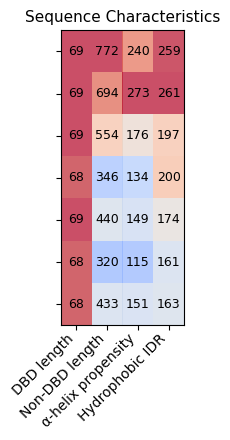

In [27]:
# Filter SOX proteins
sox_meta = seq_metadata[seq_metadata['Name'].str.startswith('SOX')]

# Plot order
plotting_order = ["SOX6", "SOX5", "SOX13", "SOX17", "SOX9", "SOX7", "SOX30"]

# Columns and labels
cols = ["domain_length", "Non_DBD_count", "helix_count", "hydrophb_count"]
labels = ["DBD length", "Non-DBD length", "α-helix propensity", "Hydrophobic IDR"]

# Prepare data
dfp = (sox_meta.assign(AA_len=sox_meta["AA_seq"].str.len())
              .set_index("Name")[cols]
              .loc[plotting_order]
              .apply(pd.to_numeric, errors="coerce")
              .fillna(0))

nrows, ncols = dfp.shape

# Plot
fig, ax = plt.subplots(figsize=(2, 4.5))

for j, col in enumerate(cols):
    col_values = dfp[col].to_numpy()[:, None]

    norm = mcolors.Normalize(vmin=col_values.min()*0.5, vmax=col_values.max())

    ax.imshow(
        col_values,
        cmap="coolwarm",
        norm=norm,
        alpha=0.7,
        aspect="auto",
        origin="upper",
        extent=(j - 0.5, j + 0.5, nrows - 0.5, -0.5),
        interpolation="nearest"
    )

ax.set_xlim(-0.5, ncols - 0.5)
ax.set_ylim(nrows - 0.5, -0.5)

ax.set_xticks(np.arange(ncols))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.tick_params(axis="x", pad=1)

ax.set_yticks(np.arange(nrows))
ax.set_yticklabels([""] * nrows)

ax.set_title("Sequence Characteristics", fontsize=11)

# Add values inside cells
for i in range(nrows):
    for j in range(ncols):
        ax.text(
            j, i, f"{int(dfp.iat[i, j])}",
            ha="center", va="center", fontsize=9,
            clip_on=True
        )

plt.tight_layout()
plt.show()